In [1]:
import os

# Estrutura YOLO
folders = [
    "Dataset/images/train",
    "Dataset/images/val",
    "Dataset/labels/train",
    "Dataset/labels/val"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Estrutura criada")

Estrutura criada


In [8]:
import shutil
import os

# Pasta onde suas imagens estão agora
origem = "imagens"   # MUDE se necessário

# Certifica-se de que os diretórios de destino existem
os.makedirs("Dataset/images/train", exist_ok=True)
os.makedirs("Dataset/images/val", exist_ok=True)

# Treino
train_imgs = [
"sandalia1_1.jpg",
"sandalia1_2.jpg",
"sandalia1_3.jpg",
"sandalia2_1.jpg",

"tenis1_1.jpg",
"tenis1_2.jpg",
"tenis1_3.jpg",
"tenis2_1.jpg"
]

# Validação
val_imgs = [
"sandalia2_2.jpg",
"sandalia2_3.jpg",

"tenis2_2.jpg",
"tenis2_3.jpg"
]

for img in train_imgs:
    shutil.copy(f"{origem}/{img}", "Dataset/images/train")

for img in val_imgs:
    shutil.copy(f"{origem}/{img}", "Dataset/images/val")

print("Imagens copiadas")

Imagens copiadas


In [9]:
print("Train:", os.listdir("Dataset/images/train"))
print()
print("Val:", os.listdir("Dataset/images/val"))

Train: ['sandalia2_1.jpg', 'sandalia1_1.jpg', 'tenis1_3.jpg', 'sandalia1_2.jpg', 'tenis1_1.jpg', 'sandalia1_3.jpg', 'tenis2_1.jpg', 'tenis1_2.jpg']

Val: ['tenis2_2.jpg', 'tenis2_3.jpg', 'sandalia2_3.jpg', 'sandalia2_2.jpg']


In [10]:
train_label_path = "Dataset/labels/train"
val_label_path = "Dataset/labels/val"

# Bounding boxes padrão
sandalia = "0 0.5 0.5 0.8 0.8"
tenis = "1 0.5 0.5 0.8 0.8"

train_labels = {
"sandalia1_1.txt": sandalia,
"sandalia1_2.txt": sandalia,
"sandalia1_3.txt": sandalia,
"sandalia2_1.txt": sandalia,

"tenis1_1.txt": tenis,
"tenis1_2.txt": tenis,
"tenis1_3.txt": tenis,
"tenis2_1.txt": tenis
}

val_labels = {
"sandalia2_2.txt": sandalia,
"sandalia2_3.txt": sandalia,

"tenis2_2.txt": tenis,
"tenis2_3.txt": tenis
}

for file, content in train_labels.items():
    with open(os.path.join(train_label_path,file),"w") as f:
        f.write(content)

for file, content in val_labels.items():
    with open(os.path.join(val_label_path,file),"w") as f:
        f.write(content)

print("Labels criados")

Labels criados


In [11]:
print("Train labels:", os.listdir("Dataset/labels/train"))
print()
print("Val labels:", os.listdir("Dataset/labels/val"))

Train labels: ['tenis1_2.txt', 'tenis1_1.txt', 'sandalia2_1.txt', 'sandalia1_2.txt', 'tenis2_1.txt', 'sandalia1_1.txt', 'tenis1_3.txt', 'sandalia1_3.txt']

Val labels: ['tenis2_3.txt', 'sandalia2_2.txt', 'tenis2_2.txt', 'sandalia2_3.txt']


In [12]:
data_yaml = """
path: Dataset

train: images/train
val: images/val

names:
  0: sandalia
  1: tenis
"""

with open("Dataset/data.yaml","w") as f:
    f.write(data_yaml)

print("data.yaml criado")

data.yaml criado


In [13]:
import yaml

with open("Dataset/data.yaml") as f:
    data = yaml.safe_load(f)

print(data)

{'path': 'Dataset', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'sandalia', 1: 'tenis'}}


In [14]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00


In [15]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [16]:
model = YOLO("yolov8n.pt")

print("Modelo carregado")

Modelo carregado


In [17]:
# Treinar o modelo (FINE TUNING)
results = model.train(
    data="Dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=4
)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

In [18]:
# teste
results = model.predict(
    source="Dataset/images/val",
    conf=0.25,
    save=True
)

print("Predição concluída")


image 1/4 /content/Dataset/images/val/sandalia2_2.jpg: 640x480 (no detections), 184.7ms
image 2/4 /content/Dataset/images/val/sandalia2_3.jpg: 640x480 (no detections), 180.6ms
image 3/4 /content/Dataset/images/val/tenis2_2.jpg: 640x480 (no detections), 163.4ms
image 4/4 /content/Dataset/images/val/tenis2_3.jpg: 640x480 (no detections), 163.5ms
Speed: 3.7ms preprocess, 173.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Predição concluída


In [19]:
os.listdir("runs/detect/predict")

['tenis2_2.jpg', 'tenis2_3.jpg', 'sandalia2_3.jpg', 'sandalia2_2.jpg']

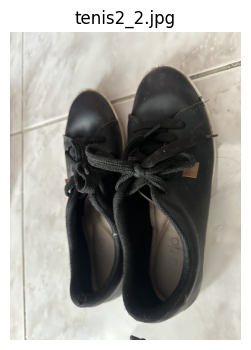

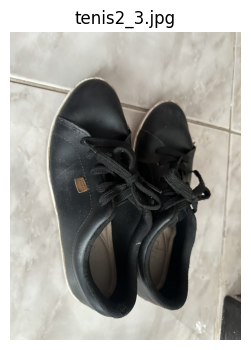

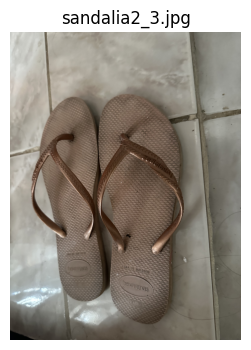

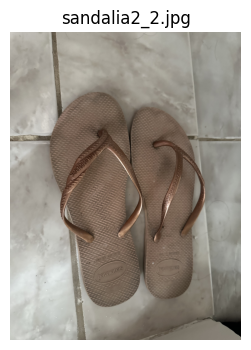

In [20]:
# Visualizar as imagens detectadas
from PIL import Image
import matplotlib.pyplot as plt


folder = "runs/detect/predict"

files = os.listdir(folder)

for f in files:
    img = Image.open(os.path.join(folder, f))

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f)
    plt.axis("off")

In [22]:
# aumentar epochs
# Re-initialize the model from the last trained weights
model = YOLO("runs/detect/train/weights/last.pt")

results = model.train(
    data="Dataset/data.yaml",
    epochs=80,
    imgsz=640,
    batch=4
)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/train/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

In [23]:
results = model.predict(
    source="Dataset/images/val",
    conf=0.15,
    save=True
)


image 1/4 /content/Dataset/images/val/sandalia2_2.jpg: 640x480 1 sandalia, 222.5ms
image 2/4 /content/Dataset/images/val/sandalia2_3.jpg: 640x480 1 sandalia, 206.3ms
image 3/4 /content/Dataset/images/val/tenis2_2.jpg: 640x480 1 tenis, 171.7ms
image 4/4 /content/Dataset/images/val/tenis2_3.jpg: 640x480 2 teniss, 177.1ms
Speed: 4.3ms preprocess, 194.4ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict2


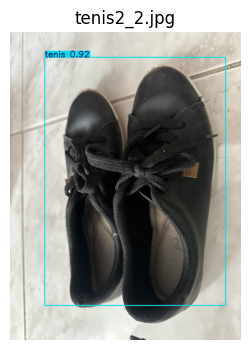

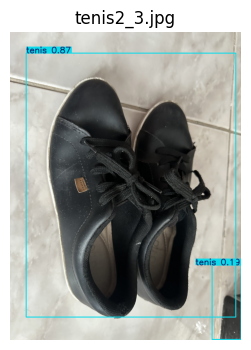

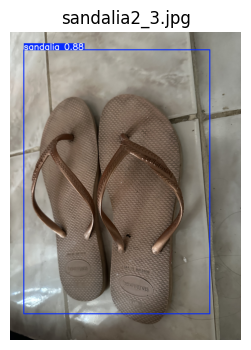

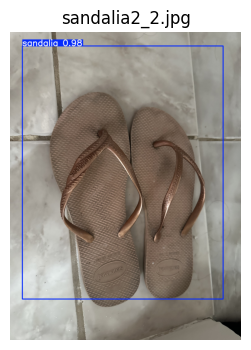

In [24]:
folder = "runs/detect/predict2"

files = os.listdir(folder)

for f in files:

    img = Image.open(os.path.join(folder, f))

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f)
    plt.axis("off")

O modelo YOLOv8 nano pré-treinado foi ajustado utilizando um conjunto de imagens próprio contendo duas classes: sandália e tênis, o mesmo dataset utilizado na disciplina anterior.

Inicialmente, o treinamento foi realizado com 30 épocas. Nessa configuração, o modelo não conseguiu detectar objetos nas imagens de validação, indicando que o número de épocas foi insuficiente para a convergência do modelo devido ao tamanho reduzido do dataset.

Em seguida, o treinamento foi repetido com 80 épocas e redução do limiar de confiança de 0.25 para 0.15. Nessa configuração, o modelo conseguiu detectar corretamente os objetos nas imagens de validação, classificando adequadamente sandálias e tênis.

Mesmo com um conjunto pequeno de dados, o fine-tuning do YOLO permitiu aprender padrões básicos de detecção de objetos. Muito massa esse projeto!!!